In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("BlackFriday_Impact_Dataset_v2.csv")
df.head()

,Transaction_ID,Year,State,Customer_ID,Customer_Type,Age_Group,Category,Product_ID,Quantity,Base_Price,Discount_Percentage,Payment_Method,BlackFriday_Week_Phase,Gender,Loyalty_Score,Final_Price
0,1,2020,VA,93127,New,56+,Fashion,1240,3,44.0,71.0,UPI,Black Friday,Female,86,12.76
1,2,2017,IA,46389,Regular,18-25,Fashion,9356,1,1534.0,8.0,UPI,Black Friday,Female,36,1411.28
2,3,2024,AK,13352,Prime,26-35,Sports,2496,4,1886.0,79.0,UPI,Black Friday,Female,85,396.06
3,4,2021,ID,93598,Prime,18-25,Fashion,1303,5,302.0,57.0,Credit,Black Friday,Other,17,129.86
4,5,2018,OK,38172,Regular,26-35,Sports,5774,4,1525.0,19.0,PayPal,Black Friday,Female,13,1235.25


In [4]:
df.shape

(12000, 16)

In [5]:
df.columns

Index(['Transaction_ID', 'Year', 'State', 'Customer_ID', 'Customer_Type',
       'Age_Group', 'Category', 'Product_ID', 'Quantity', 'Base_Price',
       'Discount_Percentage', 'Payment_Method', 'BlackFriday_Week_Phase',
       'Gender', 'Loyalty_Score', 'Final_Price'],
      dtype='object')

In [6]:
df.describe()

,Transaction_ID,Year,Customer_ID,Product_ID,Quantity,Base_Price,Discount_Percentage,Loyalty_Score,Final_Price
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,2018.991583,55099.125917,5517.111667,2.999417,1005.626250,41.875583,50.714667,582.960597
std,3464.24595,3.167993,26320.240072,2611.267199,1.419302,574.167897,21.695364,28.781124,414.087371
min,1.00000,2014.000000,10014.000000,1000.000000,1.000000,10.000000,5.000000,1.000000,2.310000
25%,3000.75000,2016.000000,31787.500000,3233.500000,2.000000,510.000000,23.000000,26.000000,252.007500
50%,6000.50000,2019.000000,55523.500000,5527.000000,3.000000,1002.000000,42.000000,51.000000,497.000000
75%,9000.25000,2022.000000,78086.750000,7758.000000,4.000000,1504.000000,61.000000,75.000000,850.805000
max,12000.00000,2024.000000,99998.000000,9998.000000,5.000000,1999.000000,79.000000,100.000000,1897.150000


In [7]:
df.isnull().sum()

Transaction_ID            0
Year                      0
State                     0
Customer_ID               0
Customer_Type             0
Age_Group                 0
Category                  0
Product_ID                0
Quantity                  0
Base_Price                0
Discount_Percentage       0
Payment_Method            0
BlackFriday_Week_Phase    0
Gender                    0
Loyalty_Score             0
Final_Price               0
dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(0)

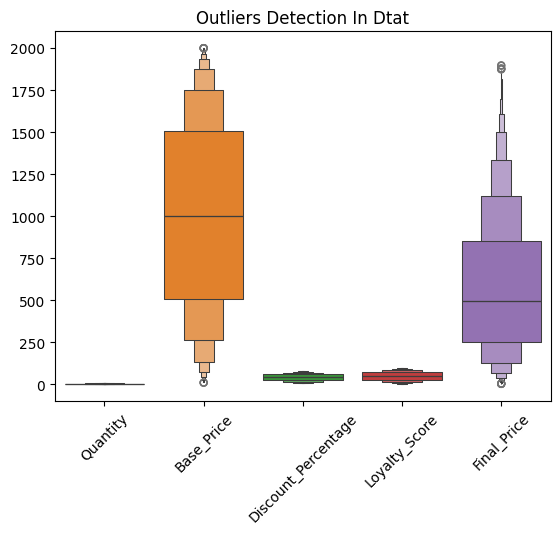

In [9]:
numeric_cols = df.select_dtypes(include=['Int64','float64']).columns
id_col = ['Transaction_ID', 'Customer_ID', 'Product_ID', 'Year']
numeric_cols = numeric_cols.drop(id_col,errors='ignore')
sns.boxenplot(data=df[numeric_cols])
plt.title('Outliers Detection In Dtat')
plt.xticks(rotation=45)
plt.show()

In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    higher = Q3+1.5*IQR
    print(f"{col}:Lower = {lower},Higher = {higher}")

Quantity:Lower = -1.0,Higher = 7.0
Base_Price:Lower = -981.0,Higher = 2995.0
Discount_Percentage:Lower = -34.0,Higher = 118.0
Loyalty_Score:Lower = -47.5,Higher = 148.5
Final_Price:Lower = -646.1887500000003,Higher = 1749.0012500000003


In [11]:
df[col]=df[col].clip(lower,higher)

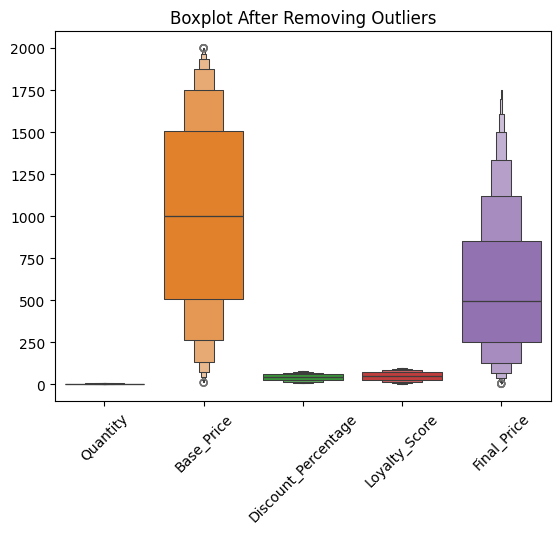

In [12]:

sns.boxenplot(data=df[numeric_cols])
plt.title("Boxplot After Removing Outliers")
plt.xticks(rotation=45)
plt.show()

In [13]:
outlier_count_after = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_count_after[col] = outliers

outlier_count_after


{'Quantity': np.int64(0),
 'Base_Price': np.int64(0),
 'Discount_Percentage': np.int64(0),
 'Loyalty_Score': np.int64(0),
 'Final_Price': np.int64(0)}

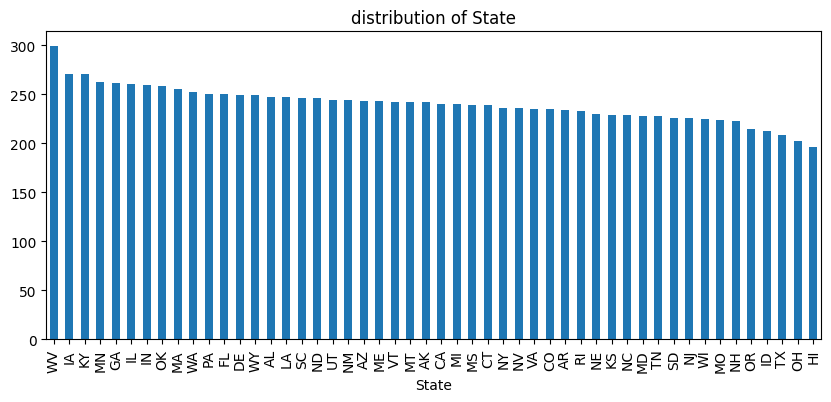

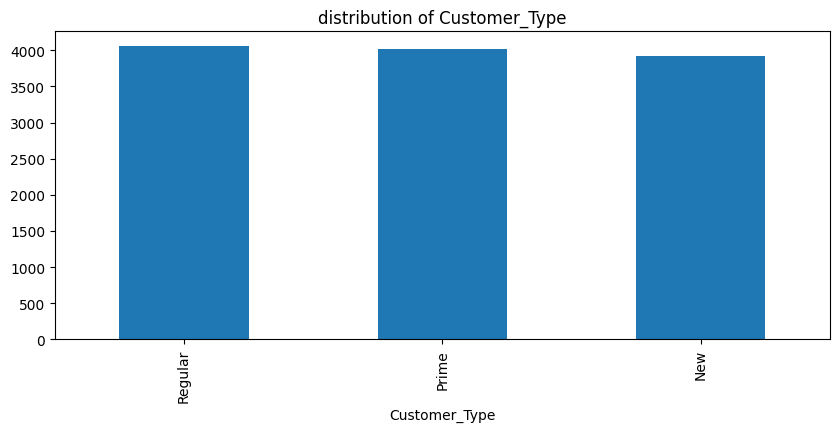

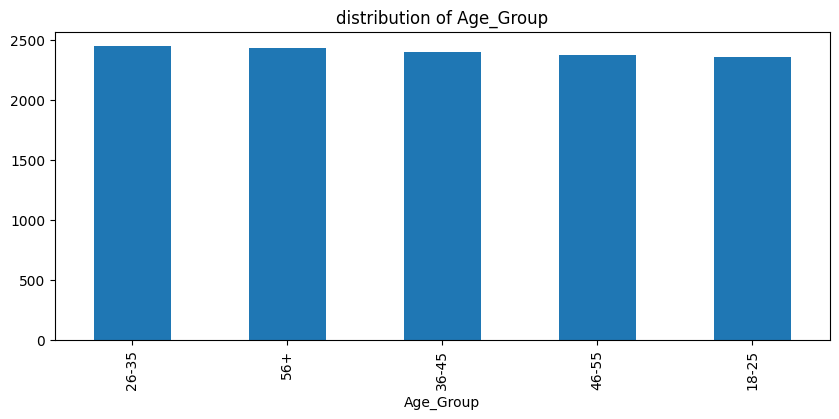

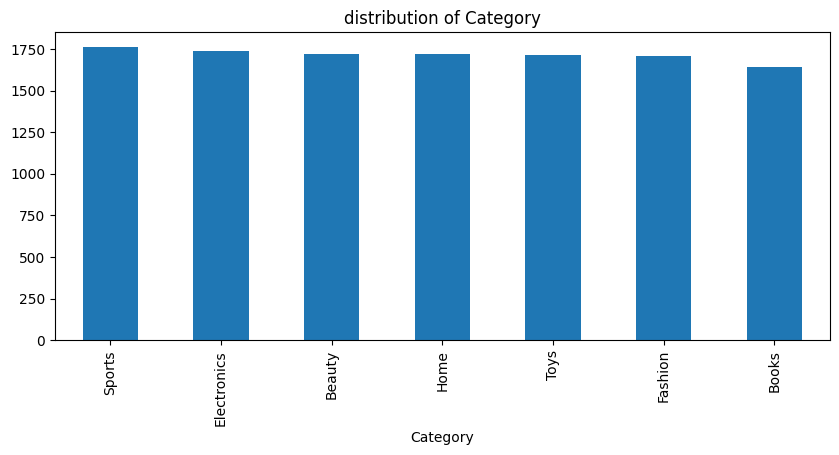

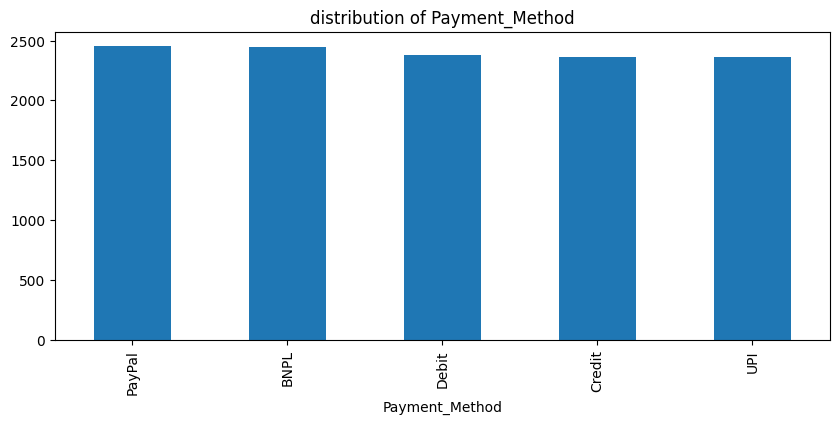

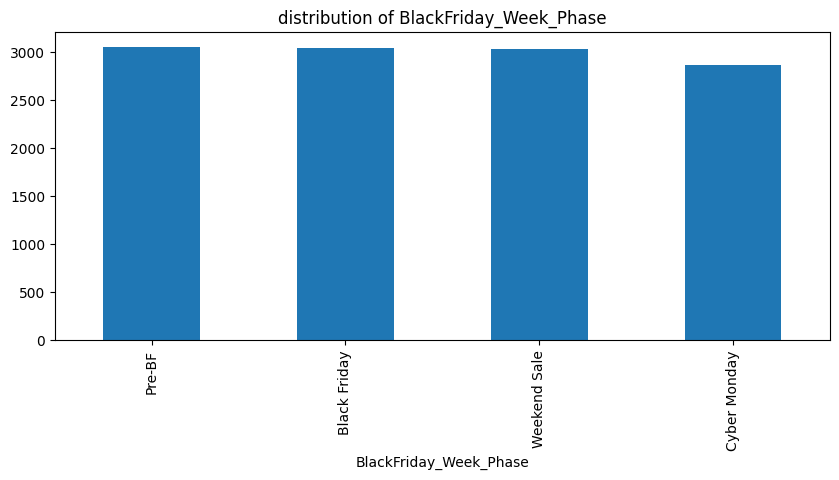

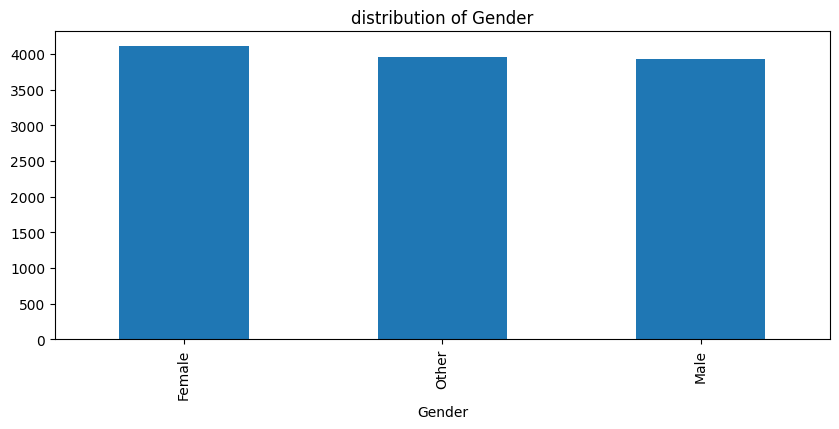

In [14]:
cat_col = df.select_dtypes(include='object').columns
for col in cat_col:
    plt.figure(figsize=(10,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"distribution of {col}")
    plt.show()


BIVARIATE ANALYSIS

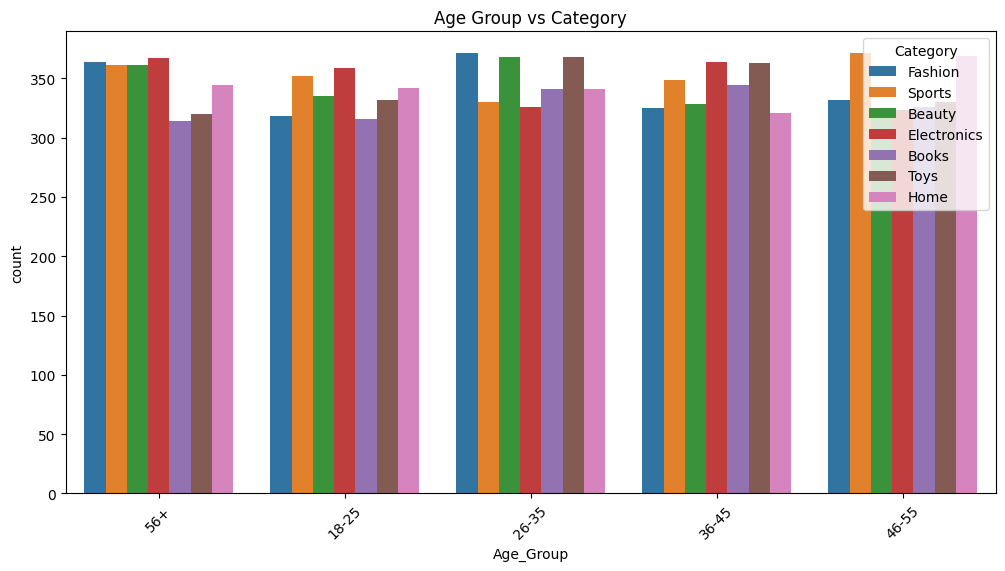

In [15]:

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Age_Group', hue='Category')
plt.title("Age Group vs Category")
plt.xticks(rotation=45)
plt.show()
